In [22]:
import os, warnings
import torch

try:
    import wget
except:
    !pip install wget

# Project 2 - Veggie Classification

For this assignment you'll need to classify some images of vegetables. 

## Parts

Please do three separate classifications:
<ol>
<li> Create a CNN model from scratch. </li>
<li> Use transfer learning to use a pretrained model of your choice, adapted to this data. </li>
<li> Create some kind of "uncommon" model, one that isn't a regular CNN or fully connected model. This is obviously a vague direction, and there isn't one specific answer. In short, I just want you to use some other model structure and compare the results to the first two. There are several choices here. I won't mark you down for not getting great performance here, or choosing an architecture that performs poorly, but within whatever you choose, the choices to train and optimize that model should be logical. </li>
</ol>

There won't be an explicit evaluation of accuracy, but you should take some steps to make each model as accurate as you reasonably can, any tuning option is fair game. Along with that, please structure it into a notebook that is well-structured and clear that explains what you did and found. Think about:
<ul>
<li> Sections and headings. 
<li> A description of the approach taken (e.g. what did you do to determine size, tune, evaluate, etc...)
<li> Visualization of some important things such as a confusion matrix and maybe some images. 
<li> Results, mainly focused on the scoring of the test data. 
</ul>

The descriptions and explanations should highlight the choices you made and why you made them. Figure up to about a page or so worth of text total, explain what happened but don't write an essay. 

## Deliverables

The primary thing that will be graded is the notebook that <b>walks a reader through what you tried and the results</b>, so, please ensure that your workbook:
<ul>
<li> Is published after being fully run, the published version should be a finished copy. </li>
<li> Is organized into sections, using headers, labels, lists, etc... to be easy to read. </li>
<li> Is cleaned up in terms of content. You will likely have some "messing around" with the data preparation to figure out exactly what you need to do. Once you've got it figured out, clean out all the experimentation (you can describe what you did in text). </li>
<li> Presents a conclusion that compares the models, identifies possible things that could make performance better, and identifies what worked and what didn't. </li>
</ul>

### Dataset

The code in the start of this notebook will download and unzip the dataset, and there is also a simple example of creating datasets. You can change the dataset bit to use a different approach if you'd like. The data is already split into train, validation, and test sets. Please treat the separate test set as the final test set, and don't use it for any training or validation. Each folder name is its own label.

### Evaluation

Marking will be based on the following:
<ul>
<li> Data preparation, cleaning, processing, pipeline: 10%. </li>
<li> Modelling and prediction is well done <b>and explained clearly:</b> 60%</li>
    <ul>
    <li> Of the modelling portion:</li>
    <li> Custom model: 50%</li>
    <li> Transfer model: 30%</li>
    <li> Strange model: 20%</li>
    </ul>
<li> Evaluation and comparison: 10%. </li>
<li> Overall ambition: 20%. </li>
    <ul>
    <li> Did you do a reasonable attempt to make a good model, or did you do the minimum to get something that functions. There are a variety of things that you can do to ensure this is a good grade (and it isn't that strict) - trying different architechtures, raytune hp searches, etc...</li>
    </ul>
</ul>

Overall the marking is pretty simple and direct, you want to show everyone that you know how to train some models to predict vegetable classes. Your notebook should demonstrate that knowledge as clearly as possible. <b>Note that you are showing off that you understand predictive modelling and training a model, so you want to demonstrate that here. This doesn't mean that "more is better" and you should throw everything you can do at the problem, but it does mean that "comprehensive is better than 'barely enough'". You want this to show that you know what you're doing. </b> 

### Tips

Some hints that may be helpful to keep in mind:
<ul>
<li> If on colab, the environment in which your code runs is temporary - storage will not persist once the session ends. </li>
<li> The data is pretty large, enough so that performance is a concern that you need to consider. In particular, be careful of batch size, you may hit the colab limits. </li>
<li> You may want to build something to manage training in multiple stages - early stopping, saving of weights, reconstructing models, etc... are all helpful things to try to sort from the start. I would figure out some way to start training, and ensure I keep the weights/model no matter what happens after that point, there are several options (generally involving something like google drive), you'll need to do a bit of research. </li>
<li> Consider a sample for quick development cycles to try things out. </li>
<li>

### Download and Unzip Data

In [23]:
def bar_custom(current, total, width=80):
    print("Downloading: %d%% [%d / %d] bytes" % (current / total * 100, current, total))
import wget
import zipfile
zip_name = "train.zip"

url = "https://jrssbcrsefilesnait.blob.core.windows.net/3950data1/vegetable_image_dataset.zip"

if not os.path.exists(zip_name):
    wget.download(url, zip_name, bar=bar_custom)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

In [24]:
# Generate Datasets - you can change this if desired
# ENSURE FILE PATHS MATCH CORRECTLY
IMAGE_SIZE=(224,224)
train_dir='Vegetable Images/train'
val_dir='Vegetable Images/validation'
batch_size = 16

# Crawl directory and get stats of files downloaded. 
import glob

train_count = len(glob.glob(os.path.join(train_dir, '**', '*.*'), recursive=True))
val_count = len(glob.glob(os.path.join(val_dir, '**', '*.*'), recursive=True))
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print(f"Training images: {train_count}")
print(f"Validation images: {val_count}")
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")


Training images: 15000
Validation images: 3000
Number of classes: 15
Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']


## Data Preparation

In [25]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch

train_transforms_cnn = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                        [0.5, 0.5, 0.5])
])

test_transforms_cnn = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                        [0.5, 0.5, 0.5])
])

test_dir = 'Vegetable Images/test'

train_dataset_cnn = datasets.ImageFolder(train_dir, transform=train_transforms_cnn)
val_dataset_cnn = datasets.ImageFolder(val_dir, transform=test_transforms_cnn)
test_dataset_cnn = datasets.ImageFolder(test_dir, transform=test_transforms_cnn)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=batch_size, shuffle=True)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=batch_size, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = test_dataset_cnn.classes
print("Classes:", classes)
print("Device:", device)

Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Device: cuda


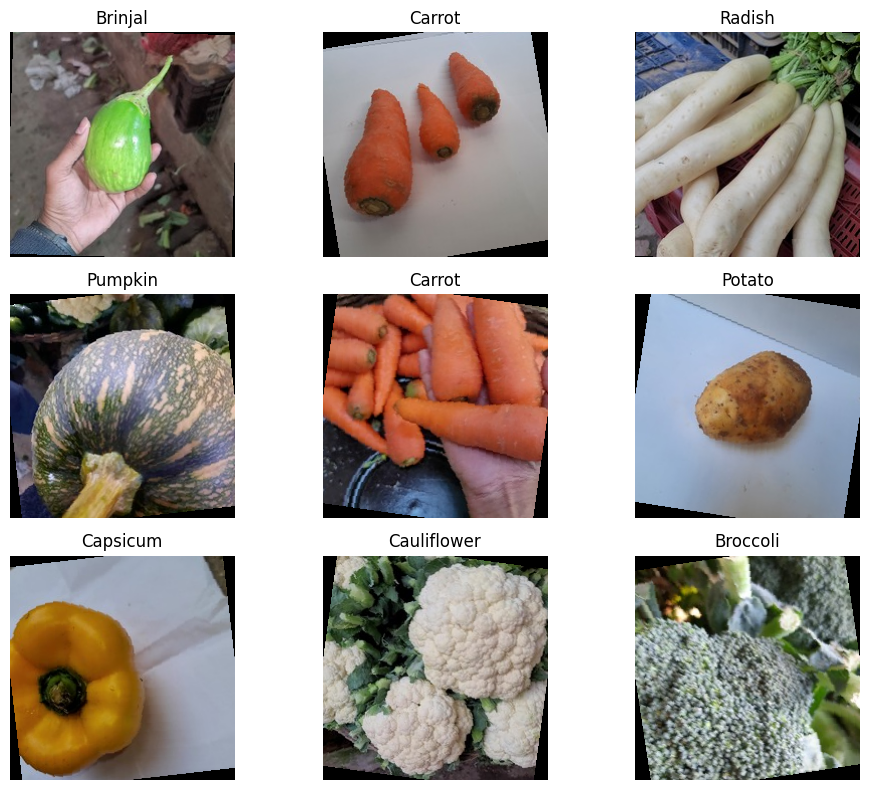

In [26]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader_cnn))

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i+1)
    img = images[i].permute(1, 2, 0).numpy()

    # unnormalize
    mean = [0.5, 0.5, 0.5]
    std = [0.5, 0.5, 0.5]
    img = img * std + mean
    img = img.clip(0, 1)

    plt.imshow(img)
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

## Custom Model Training

In [27]:
import torch.nn as nn
import torch.optim as optim

class VeggieCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, len(classes))
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

model_custom = VeggieCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_custom.parameters(), lr=0.001)

epochs = 3

for epoch in range(epochs):
    model_custom.train()
    train_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader_cnn:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_custom(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # validation
    model_custom.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader_cnn:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model_custom(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Loss 1273.6174, Train Acc 0.5458, Val Acc 0.7713
Epoch 2: Train Loss 682.9315, Train Acc 0.7652, Val Acc 0.8047
Epoch 3: Train Loss 508.3212, Train Acc 0.8299, Val Acc 0.9060


## Transfer Learning Model

In [28]:
train_transforms_resnet = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms_resnet = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dir = 'Vegetable Images/test'

train_dataset_resnet = datasets.ImageFolder(train_dir, transform=train_transforms_resnet)
val_dataset_resnet = datasets.ImageFolder(val_dir, transform=test_transforms_resnet)
test_dataset_resnet = datasets.ImageFolder(test_dir, transform=test_transforms_resnet)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = train_dataset_resnet.classes
print("Classes:", classes)
print("Device:", device)

Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Device: cuda


In [29]:
from torchvision import models

model_transfer = models.resnet18(weights='IMAGENET1K_V1')

for param in model_transfer.parameters():
    param.requires_grad = False

num_ftrs = model_transfer.fc.in_features
model_transfer.fc = nn.Linear(num_ftrs, len(classes))
model_transfer = model_transfer.to(device)

optimizer = optim.Adam(model_transfer.fc.parameters(), lr=0.001)

epochs = 3

for epoch in range(epochs):
    model_transfer.train()
    correct = 0
    total = 0

    for inputs, labels in train_loader_resnet:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_transfer(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    model_transfer.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader_resnet:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_transfer(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Acc 0.9163, Val Acc 0.9870
Epoch 2: Train Acc 0.9744, Val Acc 0.9913
Epoch 3: Train Acc 0.9831, Val Acc 0.9923


## Alternarnate Model

In [30]:
train_transforms_vit = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms_vit = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dir = 'Vegetable Images/test'

train_dataset_vit = datasets.ImageFolder(train_dir, transform=train_transforms_vit)
val_dataset_vit = datasets.ImageFolder(val_dir, transform=test_transforms_vit)
test_dataset_vit = datasets.ImageFolder(test_dir, transform=test_transforms_vit)

train_loader_vit = DataLoader(train_dataset_vit, batch_size=batch_size, shuffle=True)
val_loader_vit = DataLoader(val_dataset_vit, batch_size=batch_size, shuffle=False)
test_loader_vit = DataLoader(test_dataset_vit, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = train_dataset_vit.classes
print("Classes:", classes)
print("Device:", device)

Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Device: cuda


In [31]:
model_uncommon = models.vit_b_16(weights='IMAGENET1K_V1')

for param in model_uncommon.parameters():
    param.requires_grad = False

in_features = model_uncommon.heads.head.in_features
model_uncommon.heads.head = nn.Linear(in_features, len(classes))
model_uncommon = model_uncommon.to(device)

optimizer = optim.Adam(model_uncommon.heads.parameters(), lr=0.0005)

epochs = 3

for epoch in range(epochs):
    model_uncommon.train()
    correct = 0
    total = 0

    for inputs, labels in train_loader_vit:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_uncommon(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    model_uncommon.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader_vit:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_uncommon(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}: Train Acc {train_acc:.4f}, Val Acc {val_acc:.4f}")

Epoch 1: Train Acc 0.9607, Val Acc 0.9927
Epoch 2: Train Acc 0.9962, Val Acc 0.9947
Epoch 3: Train Acc 0.9977, Val Acc 0.9967


## Test Best Models and Illustrate Results

In [32]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

# Evaluate each model separately
y_true_cnn, y_pred_cnn = evaluate(model_custom, test_loader_cnn)
y_true_resnet, y_pred_resnet = evaluate(model_transfer, test_loader_resnet)
y_true_vit, y_pred_vit = evaluate(model_uncommon, test_loader_vit)

In [33]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

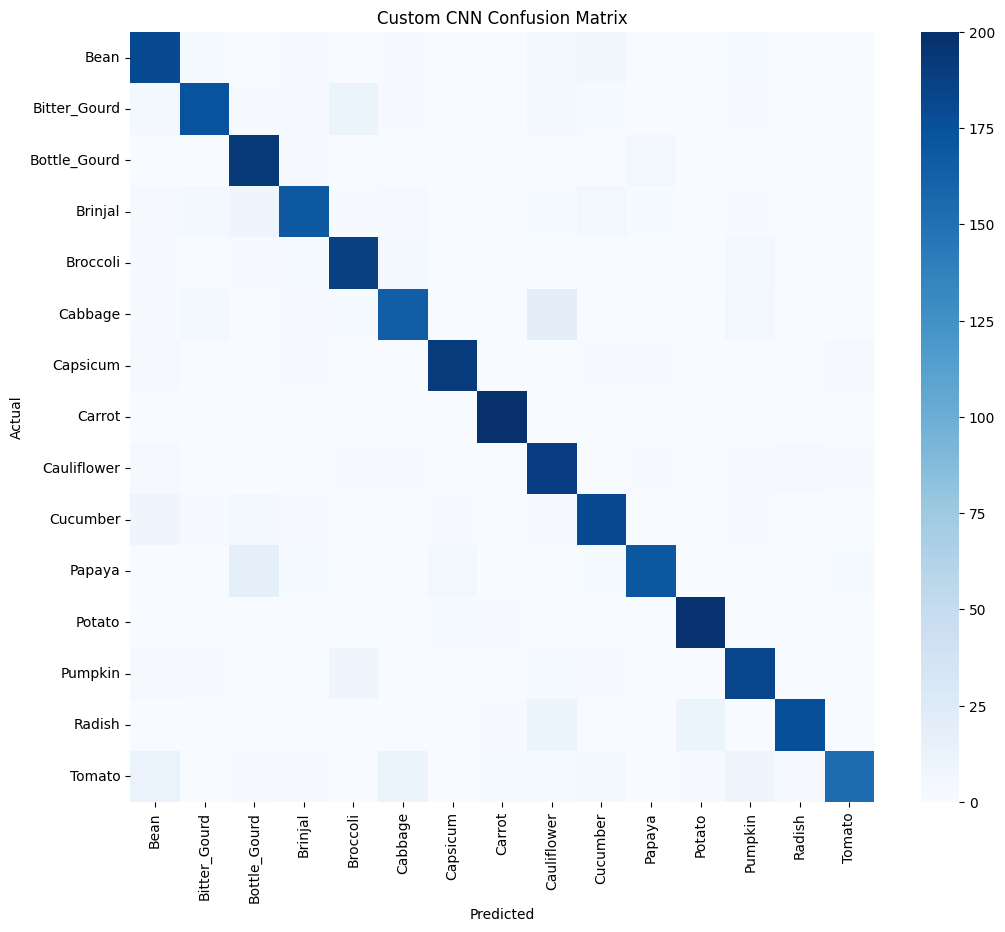

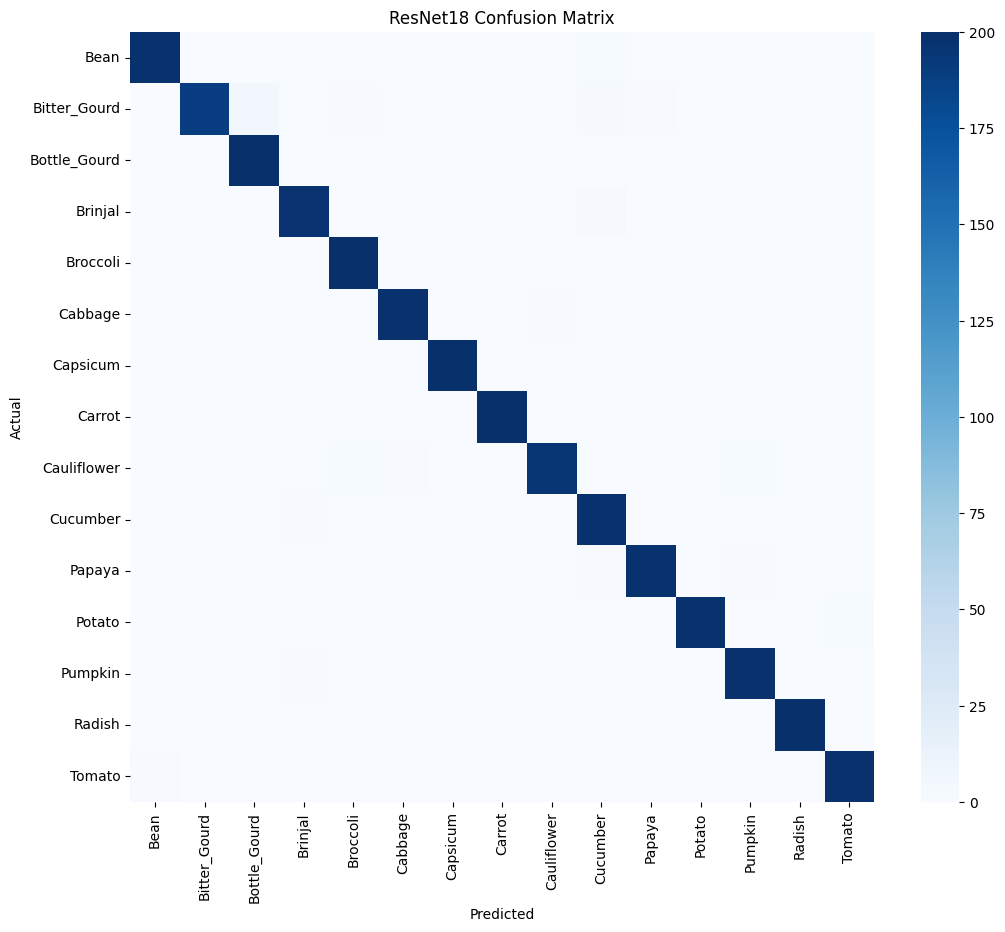

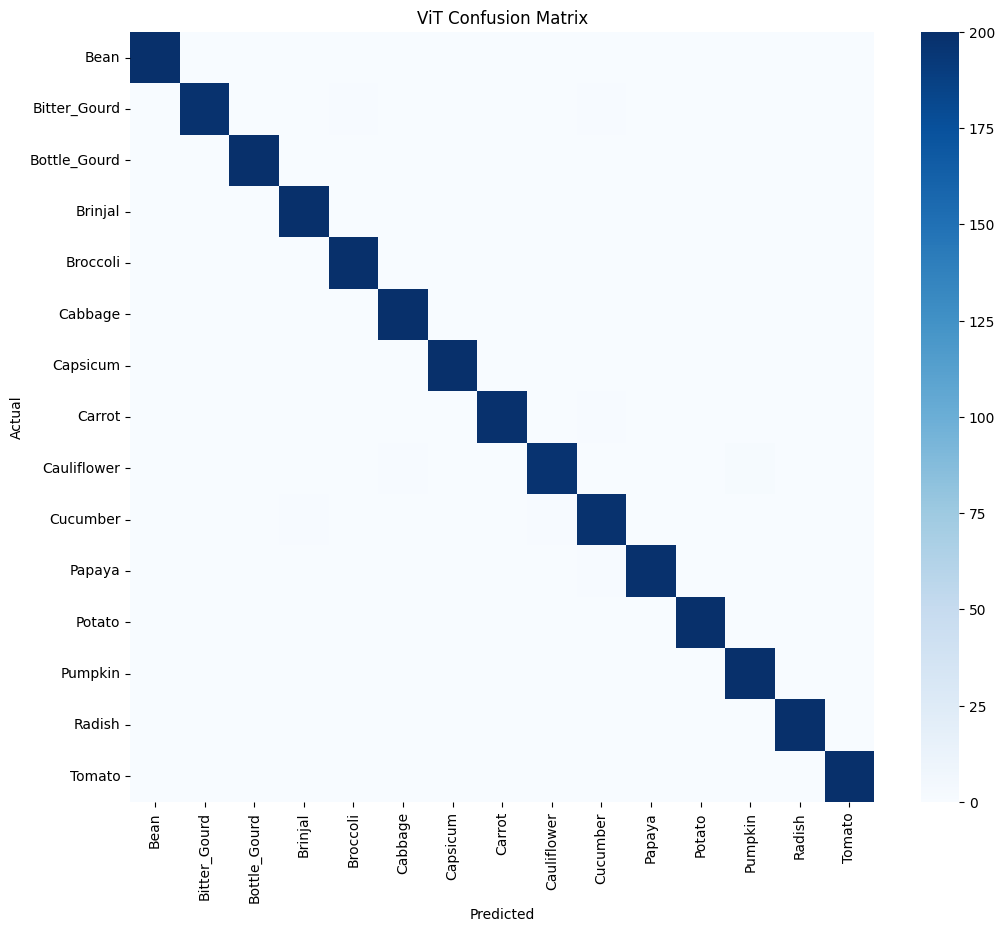

In [34]:
plot_conf_matrix(y_true_cnn, y_pred_cnn, "Custom CNN Confusion Matrix")
plot_conf_matrix(y_true_resnet, y_pred_resnet, "ResNet18 Confusion Matrix")
plot_conf_matrix(y_true_vit, y_pred_vit, "ViT Confusion Matrix")

In [35]:
cnn_acc = accuracy_score(y_true_cnn, y_pred_cnn)
resnet_acc = accuracy_score(y_true_resnet, y_pred_resnet)
vit_acc = accuracy_score(y_true_vit, y_pred_vit)

print("Custom CNN Test Accuracy:", cnn_acc)
print("ResNet18 Test Accuracy:", resnet_acc)
print("ViT Test Accuracy:", vit_acc)

Custom CNN Test Accuracy: 0.9023333333333333
ResNet18 Test Accuracy: 0.9903333333333333
ViT Test Accuracy: 0.997


In [36]:
print("Custom CNN Classification Report")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=classes))

print("ResNet18 Classification Report")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=classes))

print("ViT Classification Report")
print(classification_report(y_true_vit, y_pred_vit, target_names=classes))

Custom CNN Classification Report
              precision    recall  f1-score   support

        Bean       0.81      0.90      0.86       200
Bitter_Gourd       0.94      0.87      0.90       200
Bottle_Gourd       0.84      0.96      0.90       200
     Brinjal       0.92      0.84      0.88       200
    Broccoli       0.88      0.94      0.91       200
     Cabbage       0.89      0.82      0.85       200
    Capsicum       0.95      0.95      0.95       200
      Carrot       0.98      1.00      0.99       200
 Cauliflower       0.80      0.94      0.87       200
    Cucumber       0.88      0.90      0.89       200
      Papaya       0.94      0.85      0.89       200
      Potato       0.94      0.98      0.96       200
     Pumpkin       0.88      0.92      0.90       200
      Radish       0.98      0.88      0.93       200
      Tomato       0.96      0.77      0.85       200

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90    

In [37]:
results = {
    "Model": ["Custom CNN", "ResNet18", "ViT"],
    "Test Accuracy": [cnn_acc, resnet_acc, vit_acc]
}

import pandas as pd
results_df = pd.DataFrame(results)
results_df

,Model,Test Accuracy
0,Custom CNN,0.902333
1,ResNet18,0.990333
2,ViT,0.997000


# Final Comparison

The three models showed a clear progression in performance. The custom CNN achieved strong results, but it was outperformed by the transfer learning model, which benefited from pretrained image features. The Vision Transformer achieved the highest accuracy overall. The confusion matrix also showed that most predictions were concentrated along the diagonal, meaning that the model correctly classified most images. Only a small number of errors appeared, mainly between classes that may have similar visual characteristics.

# Conclusion

Overall, all three models performed well on the vegetable classification task, but the transfer learning and transformer-based approaches performed best. The custom CNN demonstrated that a model trained from scratch can still achieve strong results, while the pretrained ResNet18 showed the value of transfer learning. The Vision Transformer achieved the highest accuracy, likely because of its ability to capture broader relationships within images. One possible reason for the very high performance across all models is that the dataset appears relatively clean and the classes are visually distinct. In the future, performance could potentially be improved further through longer training, more data augmentation, or hyperparameter tuning. However, based on both accuracy and computational efficiency, the transfer learning model may offer the best balance between performance and practicality.